# Árvore de Decisão — Classificação do Estado do Tabuleiro


## 1. Imports e Carregamento dos Splits


In [4]:
import os
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("Carregando splits físicos...")
df_train = pd.read_csv('../../data/splits/train.csv')
df_val   = pd.read_csv('../../data/splits/val.csv')
df_test  = pd.read_csv('../../data/splits/test.csv')

X_train, y_train_raw = df_train.drop('classe', axis=1), df_train['classe']
X_val,   y_val_raw   = df_val.drop('classe', axis=1),   df_val['classe']
X_test,  y_test_raw  = df_test.drop('classe', axis=1),  df_test['classe']

le = LabelEncoder().fit(y_train_raw)
y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f"Treino:    {len(X_train):4d} amostras")
print(f"Validação: {len(X_val):4d} amostras")
print(f"Teste:     {len(X_test):4d} amostras")


Carregando splits físicos...
Treino:    1119 amostras
Validação:  241 amostras
Teste:      240 amostras


## 2. Treinamento da Árvore de Decisão


Árvore treinada.


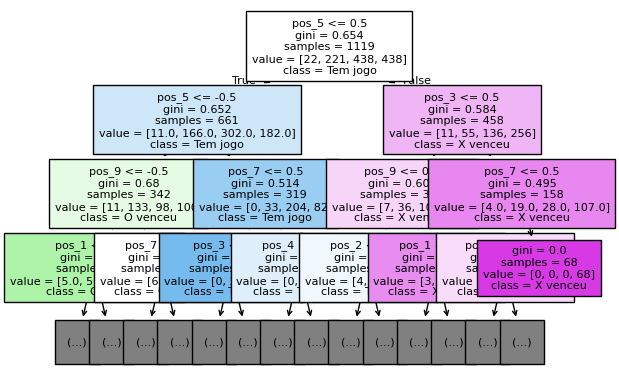

In [5]:
max_deep  = None    # Profundidade máxima
min_split = 2       # Quantas divisões são possíveis
criterion = "gini"  # 'gini', 'entropy', 'log_loss'
min_leaf  = 2

decision_tree = DecisionTreeClassifier(
    max_depth=max_deep,
    min_samples_split=min_split,
    criterion=criterion,
    min_samples_leaf=min_leaf,
    random_state=42,
)
decision_tree.fit(X_train, y_train)
print("Árvore treinada.")

plot_tree(decision_tree, max_depth=3, feature_names=X_train.columns, class_names=le.classes_, filled=True, fontsize=8)
plt.show()


## 3. Avaliação no Conjunto de Validação


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

      Empate       0.25      0.20      0.22         5
    O venceu       0.65      0.67      0.66        48
    Tem jogo       0.77      0.81      0.79        94
    X venceu       0.92      0.87      0.90        94

    accuracy                           0.79       241
   macro avg       0.65      0.64      0.64       241
weighted avg       0.79      0.79      0.79       241



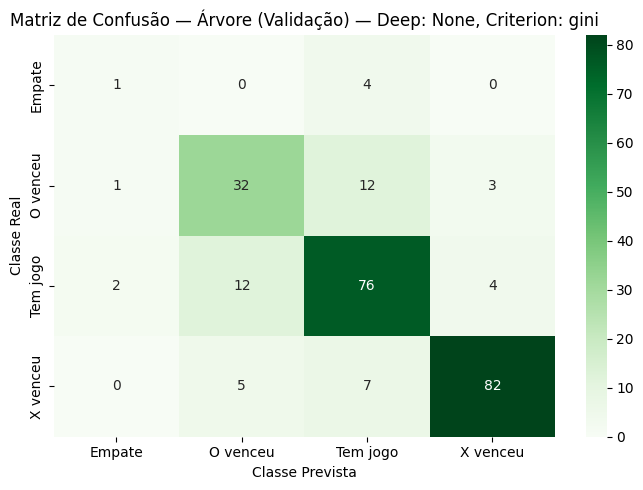

In [6]:
y_val_pred = decision_tree.predict(X_val)

print("=== VALIDAÇÃO ===")
print(classification_report(
    le.inverse_transform(y_val),
    le.inverse_transform(y_val_pred),
    zero_division=0,
))

plt.figure(figsize=(7, 5))
cm_val = confusion_matrix(le.inverse_transform(y_val), le.inverse_transform(y_val_pred), labels=le.classes_)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão — Árvore (Validação) — Deep: {max_deep}, Criterion: {criterion}')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 4. Avaliação Final no Conjunto de Teste


In [ ]:
y_test_pred = decision_tree.predict(X_test)

print("=== TESTE ===")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_test_pred),
    zero_division=0,
))

plt.figure(figsize=(7, 5))
cm_test = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_test_pred), labels=le.classes_)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão — Árvore (Teste) — Deep: {max_deep}, Criterion: {criterion}')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 5. Persistência do Modelo


In [ ]:
caminho_modelo = '../../models/DecisionTree'
os.makedirs(caminho_modelo, exist_ok=True)
joblib.dump(decision_tree, f'{caminho_modelo}/decision_tree.pkl')
joblib.dump(le,            f'{caminho_modelo}/DecisionTree_label_encoder.pkl')
print(f"Sucesso! Modelo decision tree salvo em: {caminho_modelo}")
